In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [2]:
X_test = pd.read_csv("../data/processed/X_test.csv")

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

model = joblib.load("../models/final_model.pkl")

In [3]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [4]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

In [5]:
print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

print("ROC AUC  :", roc_auc)

Accuracy : 0.9992774821132767
Precision: 0.7755102040816326
Recall   : 0.8
F1 Score : 0.7875647668393783
ROC AUC  : 0.9726961664633597


In [6]:
metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

metrics.to_csv(
    "../reports/evaluation_metrics.csv",
    index=False
)

In [7]:
report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.78      0.80      0.79        95

    accuracy                           1.00     56746
   macro avg       0.89      0.90      0.89     56746
weighted avg       1.00      1.00      1.00     56746



In [8]:
with open(
    "../reports/classification_report.txt",
    "w"
) as f:

    f.write(report)

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[56629    22]
 [   19    76]]


In [10]:
pd.DataFrame(cm).to_csv(

    "../reports/confusion_matrix.csv",

    index=False
)

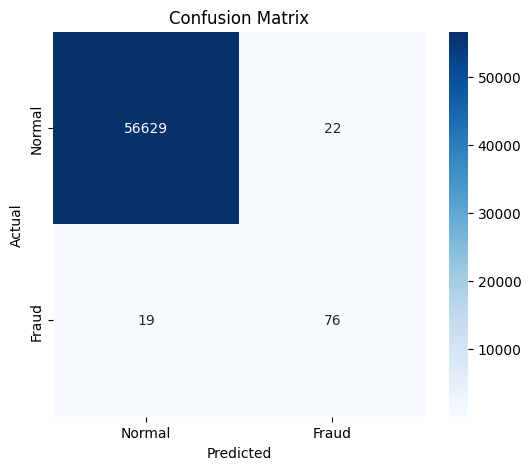

In [11]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Fraud"],
    yticklabels=["Normal","Fraud"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300
)

plt.show()

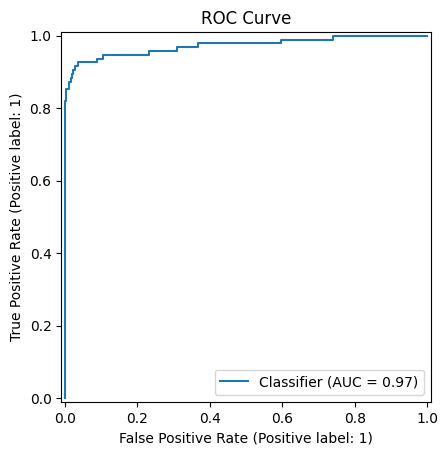

In [12]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")

plt.savefig(
    "../images/roc_curve.png",
    dpi=300
)

plt.show()

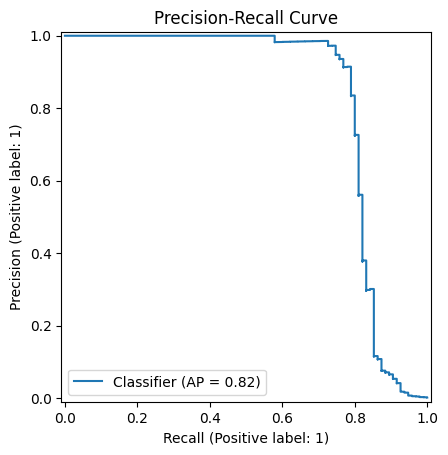

In [13]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Precision-Recall Curve")

plt.savefig(
    "../images/precision_recall_curve.png",
    dpi=300
)

plt.show()

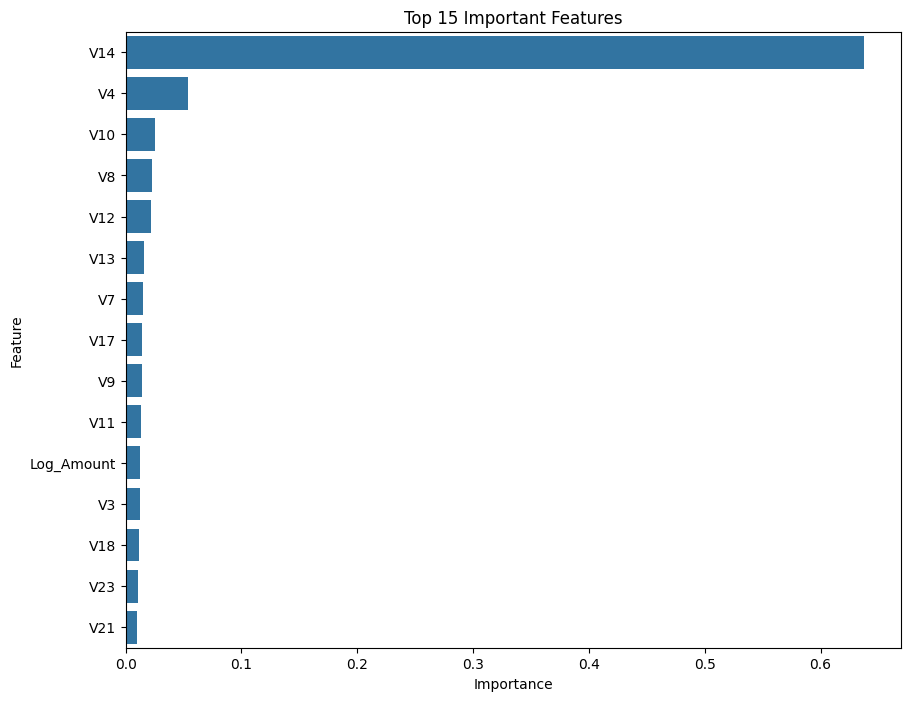

In [14]:
if hasattr(model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature":X_test.columns,

        "Importance":model.feature_importances_

    })

    importance = importance.sort_values(

        by="Importance",

        ascending=False

    )

    plt.figure(figsize=(10,8))

    sns.barplot(

        data=importance.head(15),

        x="Importance",

        y="Feature"

    )

    plt.title("Top 15 Important Features")

    plt.savefig(
        "../images/feature_importance.png",
        dpi=300
    )

    plt.show()